In [16]:
#import of libreries and setup of pandas' configuration
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import (GradientBoostingRegressor,HistGradientBoostingRegressor, RandomForestRegressor)

pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

print("libreries imported")

libreries imported


In [17]:
#upload dataset
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='forward')

eff_move=[1,2,3,4,5,6,7,8,9,10]

#calculation of pyshical move
datafile["eff_mean"]= datafile[eff_move].mean(axis=1)
datafile["std"]=datafile[eff_move].std(axis=1)
datafile["th_err"]= datafile["eff_mean"]- datafile["th_move"]
#delete of empty row or Nan row
datafile = datafile.dropna(subset=["time", "power","th_err","std"])
#preview of some data
datafile[["time","power","th_move","eff_mean","std","th_err"]].head()

,time,power,th_move,eff_mean,std,th_err
0,100.0,0.1,0.1,0.220,0.070711,0.120
1,200.0,0.1,0.2,0.341,0.077667,0.141
2,300.0,0.1,0.3,0.426,0.207750,0.126
3,400.0,0.1,0.4,0.700,0.142906,0.300
4,500.0,0.1,0.5,0.692,0.056135,0.192


In [18]:
x=datafile[["time", "power"]].values
y_err=datafile["th_err"].values
y_std=datafile["std"].values

best_degree=2
best_r2=-np.inf

#5 fold Cross-validation
kf= KFold(n_splits=5,shuffle=True, random_state=43)

#assesment of the best degree
for degree in [2,3,4,5]:
    poly= PolynomialFeatures(degree=degree)
    x_poly=poly.fit_transform(x)

    #assesment of the stability of the error model
    scores = cross_val_score(LinearRegression(), x_poly, y_err,cv=kf,scoring="r2")
    mean_r2=np.mean(scores)

    print(f"degree{degree} -> mean R2(cross_validation):{mean_r2:.4f}")

    if mean_r2 >best_r2:
        best_r2=mean_r2
        best_degree=degree

print(f"\nbest degree ->{best_degree}")

degree2 -> mean R2(cross_validation):0.9481
degree3 -> mean R2(cross_validation):0.9513
degree4 -> mean R2(cross_validation):0.9565
degree5 -> mean R2(cross_validation):0.9562

best degree ->4


In [19]:
#training of error model and std model
best_poly=PolynomialFeatures(degree=best_degree)
x_poly_best=best_poly.fit_transform(x)

#error model
model_err=LinearRegression()
model_err.fit(x_poly_best, y_err)
#std model
model_std=LinearRegression()
model_std.fit(x_poly_best, y_std)

#metric calculation
y_err_pred=model_err.predict(x_poly_best)
y_std_pred=model_std.predict(x_poly_best)

print(f"\n error metrics")
#error metrics
print(f"R2: {r2_score(y_err,y_err_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_err,y_err_pred):.4f} m")
print(f"RMSE: {np.sqrt(mean_squared_error(y_err,y_err_pred)):.4f} m")

print(f"\n std metrics")
#std metrics
print(f"R2: {r2_score(y_std,y_std_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_std,y_std_pred):.4f} m")


 error metrics
R2: 0.9853
MAE: 0.0484 m
RMSE: 0.0673 m

 std metrics
R2: 0.3720
MAE: 0.0306 m


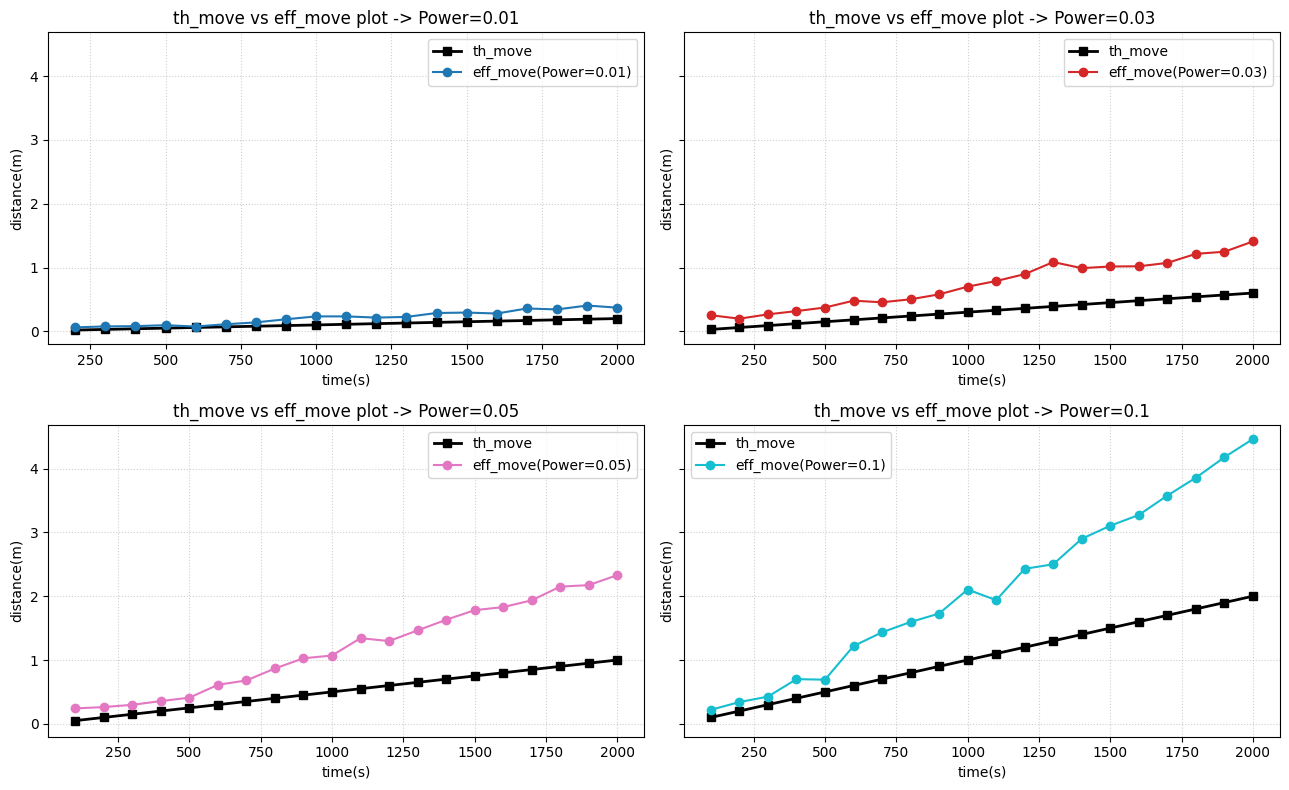

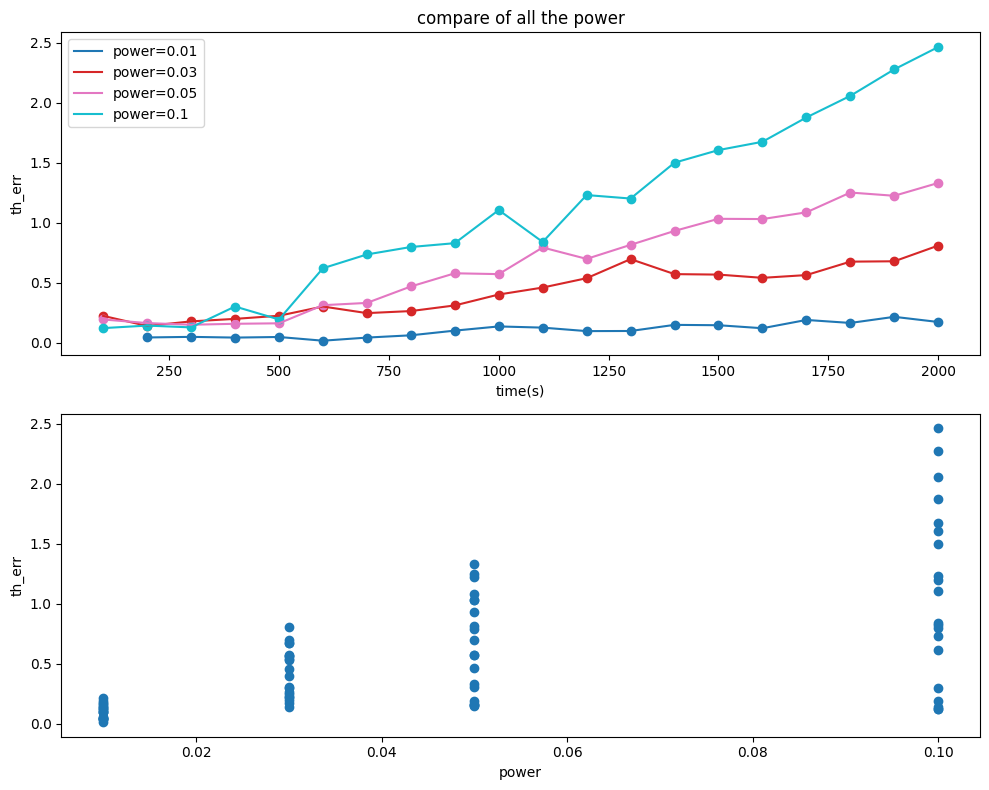

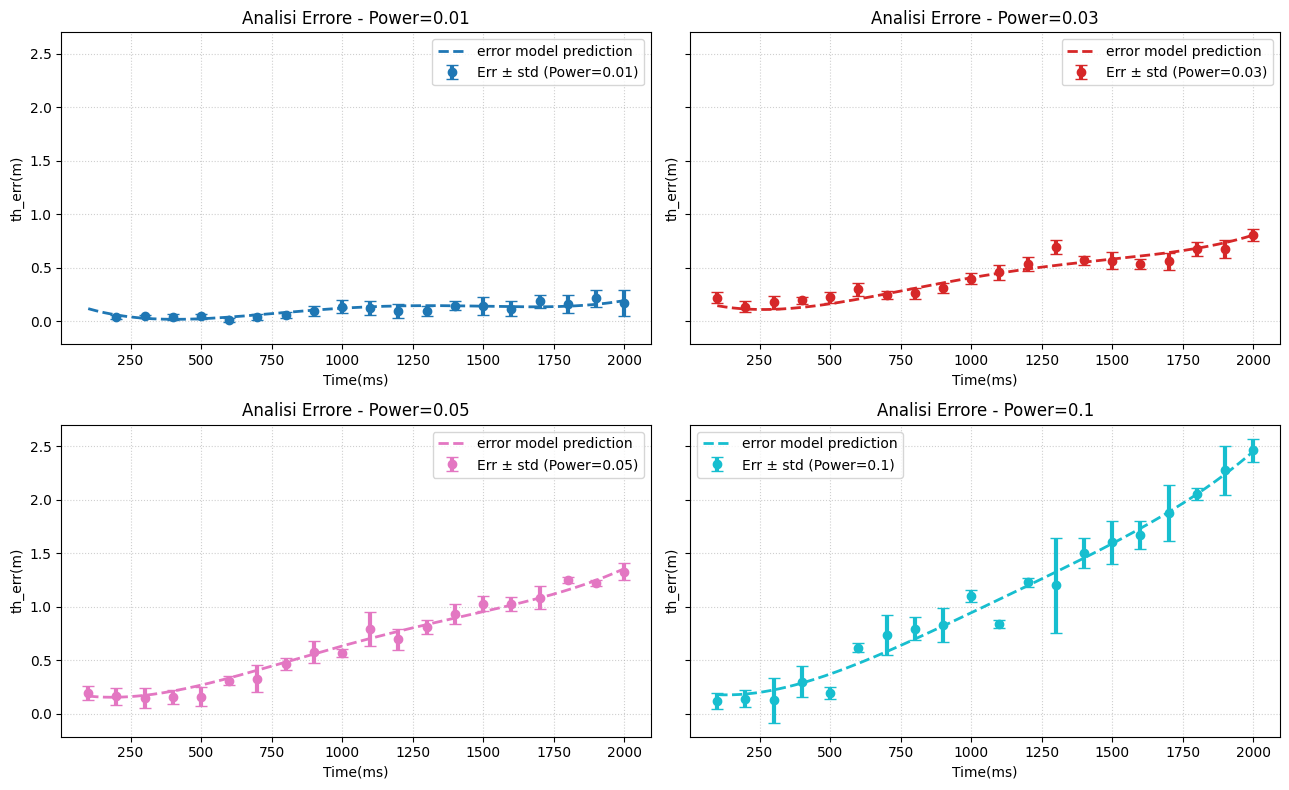

In [20]:
powervalues= np.sort(datafile["power"].unique())
colors = cm.tab10(np.linspace(0,1,len(powervalues)))

n_powers = len(powervalues)
cols=2
rows = (n_powers+1) // 2
timerange=np.linspace(datafile["time"].min(), datafile["time"].max(),200)

#th_move vs eff_move plot
fig, axes =plt.subplots(rows,cols,figsize=(13,4*rows),sharey=True)
axes= np.array(axes).flatten()

for ax, powerval, color in zip(axes,powervalues,colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")

    ax.plot(subset["time"],subset["th_move"], color="black",linewidth=2,marker="s",linestyle="-",label="th_move")
    ax.plot(subset["time"],subset["eff_mean"], "o-", color=color, linewidth=1.5,label=f"eff_move(Power={powerval})")

    ax.set_xlabel("time(s)")
    ax.set_ylabel("distance(m)")
    ax.set_title(f"th_move vs eff_move plot -> Power={powerval}")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

for i in range (n_powers,len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(10,8))

for powerval, color in zip(powervalues, colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")
    ax1.scatter(subset["time"], subset["th_err"], color= color)
    ax1.plot(subset["time"],subset["th_err"],color=color,label=(f"power={powerval}"))
    
ax1.set_xlabel("time(s)")
ax1.set_ylabel("th_err")
ax1.set_title(f"compare of all the power")
ax1.legend()

ax2.scatter(datafile["power"],datafile["th_err"])
ax2.set_xlabel("power")
ax2.set_ylabel("th_err")
plt.tight_layout()
plt.show()

fig3, axes3=plt.subplots(rows,cols,figsize=(13,4*rows),sharey=True)
axes3=np.array(axes3).flatten()

for ax, powerval,color in zip(axes3,powervalues,colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")
    ax.errorbar(subset["time"],subset["th_err"],yerr=subset["std"],fmt='o', color=color,ecolor=color,capsize=4,elinewidth=3,label=f"Err ± std (Power={powerval})")
    x_curve=np.column_stack([timerange, np.full_like(timerange,powerval)])
    x_curve_poly=best_poly.transform(x_curve)
    y_curve_err=model_err.predict(x_curve_poly)

    ax.plot(timerange,y_curve_err, color=color, linewidth=2, linestyle="--", label="error model prediction")
    ax.set_xlabel("Time(ms)")
    ax.set_ylabel("th_err(m)")
    ax.set_title(f"Analisi Errore - Power={powerval}")
    ax.grid(True,linestyle=":",alpha=0.6)
    ax.legend()

for i in range (n_powers,len(axes3)):
    fig3.delaxes(axes3[i])

plt.tight_layout()
plt.show()

In [23]:
#calulation of metrics to be sure that i chose the right model
pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

datafile = pd.read_excel("test.ods",engine="odf", sheet_name='forward')
eff_move=[1,2,3,4,5,6,7,8,9,10]

datafile["th_err"]= datafile[eff_move].mean(axis=1)-datafile["th_move"]
datafile = datafile.dropna(subset=["time", "power","th_err"])

x_orig=datafile[["time", "power"]].values
y=datafile["th_err"].values
            
xtrain ,xtest, ytrain, ytest = train_test_split(x_orig,y, test_size=0.2, random_state=43)

LR = LinearRegression()
HGBR=HistGradientBoostingRegressor(random_state=43)
GBR=GradientBoostingRegressor(random_state=43)
RFR=RandomForestRegressor(n_jobs=-1,random_state=43)

bestr2=-9999
bestmodel=None
best_mae=0
best_rmse=0

summary_list=[]

#compare of the different model
for model in [LR,GBR,HGBR,RFR]:
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)
    r2= r2_score(ytest, ypred)
    mae=mean_absolute_error(ytest,ypred)
    rmse=np.sqrt(mean_squared_error(ytest,ypred))
    model_name=model.__class__.__name__
    summary_list.append({"Model": model_name, "R2": r2,"MAE":mae, "RMSE":rmse})

    if r2>bestr2:
        bestr2 = r2
        bestmodel= model_name
        best_mae=mae
        best_rmse=rmse

df_summary=pd.DataFrame(summary_list).sort_values(by="R2",ascending=False)
print("Compare of all model")
print(df_summary.to_string(index=False))
print("\n")
print("best model: ", bestmodel)
print("R2: ", bestr2)
print("MAE: ", best_mae)
print("RMSE: ", best_rmse)

Compare of all model
                        Model       R2      MAE     RMSE
        RandomForestRegressor 0.965241 0.068701 0.102219
    GradientBoostingRegressor 0.950237 0.086271 0.122308
HistGradientBoostingRegressor 0.817922 0.197086 0.233953
             LinearRegression 0.721500 0.249315 0.289343


best model:  RandomForestRegressor
R2:  0.9652414977263508
MAE:  0.0687006249999998
RMSE:  0.10221875864414492


In [24]:
#this part is needed to export the result of the model

#save the trained linear regression model as a .joblib file
joblib.dump(model_err,"model_err.joblib")

#save the polynomialFeatures transformer object
joblib.dump(best_poly, "best_poly.joblib")
print("model saved as 'model_err.joblib' and 'best_poly.joblib'")

#EXTRACT THE MATHEMATICAL PARAMETER FOR KOTLIN
#extract the intercept 'q' and convert it to a standard python float
intercept=float(model_err.intercept_)

#extract angular coefficients 'm' and convert from array Numpy to Python list
coefficients=model_err.coef_.tolist()

#extract the exponent combination matrix as a python list
powers= best_poly.powers_.tolist()

#create a structured dictionary containing all metadata needed by kotlin
export_data={"model_type": "PolynomialRegression", "degree": int(best_poly.degree), "features":["time","power"],"intercept":intercept,
             "coefficients":coefficients, "powers": powers}

#EXPORT TO JSON FILE

json_filename="model_coefficient.json"
#write the parameters dictionary into a json file with 4 space indentation
with open(json_filename,"w") as f:
    json.dump(export_data, f, indent=4)

print(f"file exported with success in json: '{json_filename}'\n")

print("\n PRE VIEW OF JSON FILE STRUCTURE")
print(json.dumps(export_data, indent=4))

print("\n MATH EQUATION")

#initialize the equation term list starting with the formatted intercept
terms=[f"{intercept:.6f}"]

#iterate simultaneously through each coefficient and its corresponding exponent pair
for coef, p in zip(coefficients,powers):
    #ignore near zero coefficients for cleaner representation
    if abs(coef)> 1e-8:
        t_exp, p_exp=p[0],p[1]

        #format the numerical coefficient with its sign and 6 decimal places 
        term_str=f"{coef:+.6f}"

        #append 'time' feature string if its exponent is greater than 0
        if t_exp==1:
            term_str +=" * time"
        elif t_exp >1:
            term_str +=f" * time^{t_exp}"

        #append 'power' feature string if its exponent is greater than 0
        if p_exp==1:
            term_str +=" * power"
        elif p_exp>1:
            term_str +=f" * power^{p_exp}"

        terms.append(term_str)
#join all equation terms into a single formatted string
equation="th_err=" + " ".join(terms)

#print the readable algebraic formula
print(equation)

model saved as 'model_err.joblib' and 'best_poly.joblib'
file exported with success in json: 'model_coefficient.json'


 PRE VIEW OF JSON FILE STRUCTURE
{
    "model_type": "PolynomialRegression",
    "degree": 4,
    "features": [
        "time",
        "power"
    ],
    "intercept": 0.21262127194632113,
    "coefficients": [
        0.0,
        -0.0013197672095516162,
        6.183313260951855e-06,
        2.1994817376173405e-06,
        0.018111836928820717,
        -0.0002035722587277167,
        -1.4538224625531488e-09,
        -1.4494794269555507e-06,
        -0.10373060172221216,
        -3.175073032169694e-05,
        3.202577092409342e-13,
        4.0185318783487187e-10,
        3.3273178733076263e-05,
        -0.01628954101601957,
        -3.730757257840933e-06
    ],
    "powers": [
        [
            0,
            0
        ],
        [
            1,
            0
        ],
        [
            0,
            1
        ],
        [
            2,
            0
   